In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
#    for filename in filenames:
#        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
%cd /kaggle/working
!git clone https://github.com/orietur326/cifake-detection-project.git

/kaggle/working
Cloning into 'cifake-detection-project'...
remote: Enumerating objects: 99, done.
remote: Counting objects: 100% (99/99), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 99 (delta 35), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (99/99), 684.94 KiB | 7.87 MiB/s, done.
Resolving deltas: 100% (35/35), done.


In [3]:
%cd /kaggle/working/cifake-detection-project
!git pull

/kaggle/working/cifake-detection-project
Already up to date.


In [4]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [5]:
!ls -la /kaggle/working

total 48
drwxr-xr-x 3 root root  4096 May 10 09:37 .
drwxr-xr-x 8 root root  4096 May 10 09:37 ..
drwxr-xr-x 7 root root  4096 May 10 09:37 cifake-detection-project
---------- 1 root root 36842 May 10 09:37 __notebook__.ipynb


In [6]:
%cd /kaggle/working/cifake-detection-project

/kaggle/working/cifake-detection-project


In [7]:
import os

base = "/kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images"

for split in ["train", "test"]:
    for cls in ["REAL", "FAKE"]:
        path = f"{base}/{split}/{cls}"
        print(path, len(os.listdir(path)))

/kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/train/REAL 50000
/kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/train/FAKE 50000
/kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/test/REAL 10000
/kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/test/FAKE 10000


In [8]:
!python -m src.train_resnet18 \
  --data_dir /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images \
  --fast_dev_run \
  --num_workers 0 \
  --max_train_each 20 \
  --max_test_each 20 \
  --epochs 1 \
  --batch_size 8

fast_dev_run enabled with overrides: max_train_each=20, max_test_each=20, epochs=1, batch_size=8, num_workers=0
Using device: cuda
Validated CIFAKE directory structure at: /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images
fast_dev_run enabled in data loading: max_train_each=20, max_test_each=20
collecting train REAL
Entering folder scan: /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/train/REAL
collected train REAL: 20
collecting train FAKE
Entering folder scan: /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/train/FAKE
collected train FAKE: 20
collecting test REAL
Entering folder scan: /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/test/REAL
collected test REAL: 20
collecting test FAKE
Entering folder scan: /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/test/FAKE
collected test FAKE: 20
Collected sample counts -> train: 40, test: 40
Spl

正式训练 - 5epochs

In [9]:
!python -m src.train_resnet18 \
  --data_dir /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images \
  --epochs 5 \
  --batch_size 128 \
  --learning_rate 1e-3 \
  --num_workers 2 \
  --max_train_each 25000 \
  --max_test_each 5000

Using device: cuda
Validated CIFAKE directory structure at: /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images
collecting train REAL
Entering folder scan: /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/train/REAL
collected train REAL: 25000
collecting train FAKE
Entering folder scan: /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/train/FAKE
collected train FAKE: 25000
collecting test REAL
Entering folder scan: /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/test/REAL
collected test REAL: 5000
collecting test FAKE
Entering folder scan: /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/test/FAKE
collected test FAKE: 5000
Collected sample counts -> train: 50000, test: 10000
Split sample counts -> train: 40000, val: 10000, test: 10000
DataLoader config -> batch_size=128, num_workers=2, train_batches=313, val_batches=79
Starting training loop. Fi

In [10]:
!find outputs -maxdepth 3 -type f

outputs/resnet18/training_log.csv
outputs/resnet18/best_resnet18.pth


In [11]:
!python -m src.eval_resnet18 \
  --data_dir /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images \
  --checkpoint outputs/resnet18/best_resnet18.pth \
  --batch_size 128 \
  --num_workers 2

Using device: cuda
Validated CIFAKE directory structure at: /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images
collecting train REAL
Entering folder scan: /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/train/REAL
collected train REAL: 50000
collecting train FAKE
Entering folder scan: /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/train/FAKE
collected train FAKE: 50000
collecting test REAL
Entering folder scan: /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/test/REAL
collected test REAL: 10000
collecting test FAKE
Entering folder scan: /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/test/FAKE
collected test FAKE: 10000
Collected sample counts -> train: 100000, test: 20000
{
  "accuracy": 0.94775,
  "f1": 0.9481878129803163
}
Saved summary: outputs/resnet18/resnet18_clean_results.csv
Saved classification report: outputs/resnet18/resnet18_cl

Final-version

In [12]:
!python -m src.train_resnet18 \
  --data_dir /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images \
  --epochs 10 \
  --batch_size 128 \
  --learning_rate 1e-3 \
  --num_workers 2

Using device: cuda
Validated CIFAKE directory structure at: /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images
collecting train REAL
Entering folder scan: /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/train/REAL
collected train REAL: 50000
collecting train FAKE
Entering folder scan: /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/train/FAKE
collected train FAKE: 50000
collecting test REAL
Entering folder scan: /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/test/REAL
collected test REAL: 10000
collecting test FAKE
Entering folder scan: /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/test/FAKE
collected test FAKE: 10000
Collected sample counts -> train: 100000, test: 20000
Split sample counts -> train: 80000, val: 20000, test: 20000
DataLoader config -> batch_size=128, num_workers=2, train_batches=625, val_batches=157
Starting training loop

In [13]:
!python -m src.eval_resnet18 \
  --data_dir /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images \
  --checkpoint outputs/resnet18/best_resnet18.pth \
  --batch_size 128 \
  --num_workers 2

Using device: cuda
Validated CIFAKE directory structure at: /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images
collecting train REAL
Entering folder scan: /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/train/REAL
collected train REAL: 50000
collecting train FAKE
Entering folder scan: /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/train/FAKE
collected train FAKE: 50000
collecting test REAL
Entering folder scan: /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/test/REAL
collected test REAL: 10000
collecting test FAKE
Entering folder scan: /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/test/FAKE
collected test FAKE: 10000
Collected sample counts -> train: 100000, test: 20000
{
  "accuracy": 0.9578,
  "f1": 0.9577577577577577
}
Saved summary: outputs/resnet18/resnet18_clean_results.csv
Saved classification report: outputs/resnet18/resnet18_cla

鲁棒性

In [14]:
!python -m src.eval_resnet18_robustness \
  --data_dir /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images \
  --checkpoint outputs/resnet18/best_resnet18.pth \
  --batch_size 128 \
  --num_workers 2

Using device: cuda
Validated CIFAKE directory structure at: /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images
collecting train REAL
Entering folder scan: /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/train/REAL
collected train REAL: 50000
collecting train FAKE
Entering folder scan: /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/train/FAKE
collected train FAKE: 50000
collecting test REAL
Entering folder scan: /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/test/REAL
collected test REAL: 10000
collecting test FAKE
Entering folder scan: /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/test/FAKE
collected test FAKE: 10000
Collected sample counts -> train: 100000, test: 20000
{
  "clean_acc": 0.9578,
  "clean_f1": 0.9577577577577577
}
      model      corruption level  clean_acc      acc     drop        f1
0  resnet18           clean  none    

可视化

In [15]:
!python -m src.plot_results

Saved clean comparison CSV: outputs/final_comparison/model_comparison_clean.csv
[WARNING] ML robustness CSV not found: outputs/robustness_results.csv
Saved robustness curves: outputs/final_comparison/robustness_curves_all_models.png
Saved drop heatmap: outputs/final_comparison/drop_heatmap_all_models.png


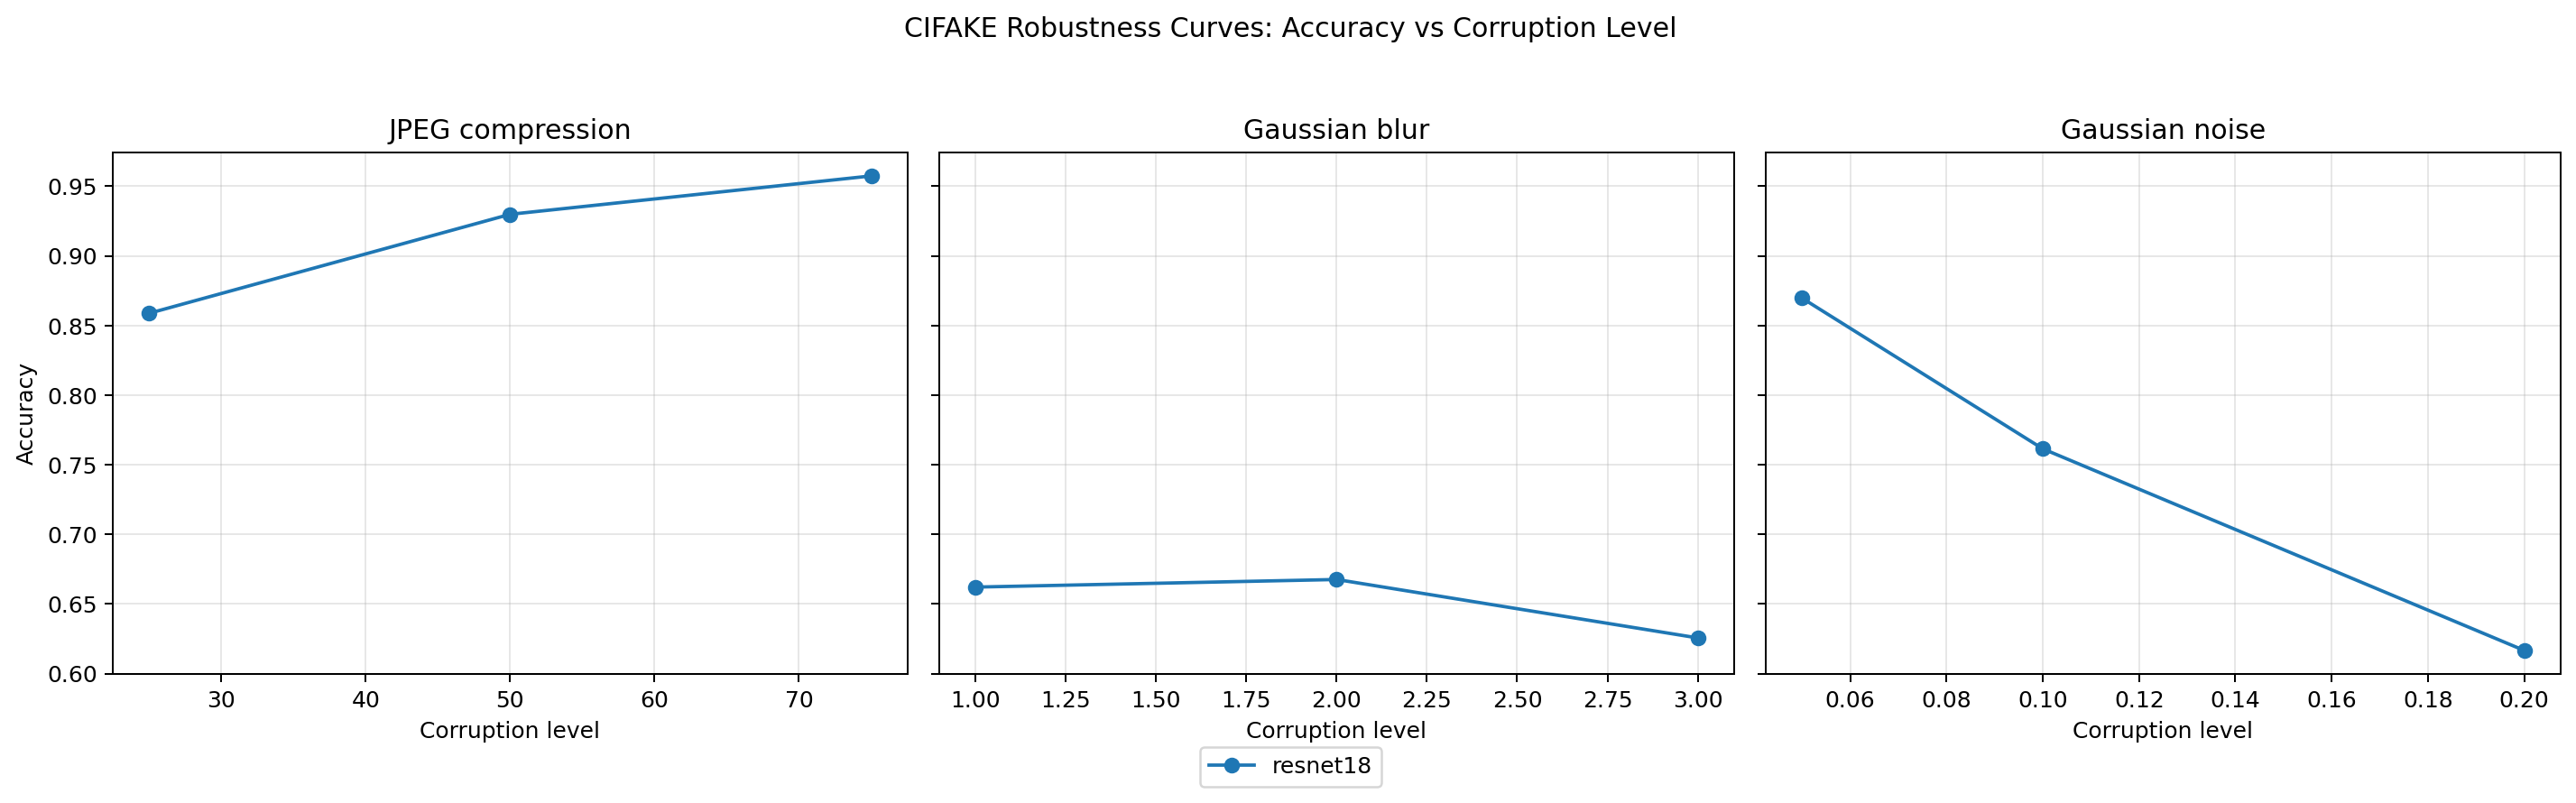

In [16]:
from IPython.display import Image, display

display(Image("outputs/final_comparison/robustness_curves_all_models.png"))

Found 3 PNG files.



## final_comparison/drop_heatmap_all_models.png

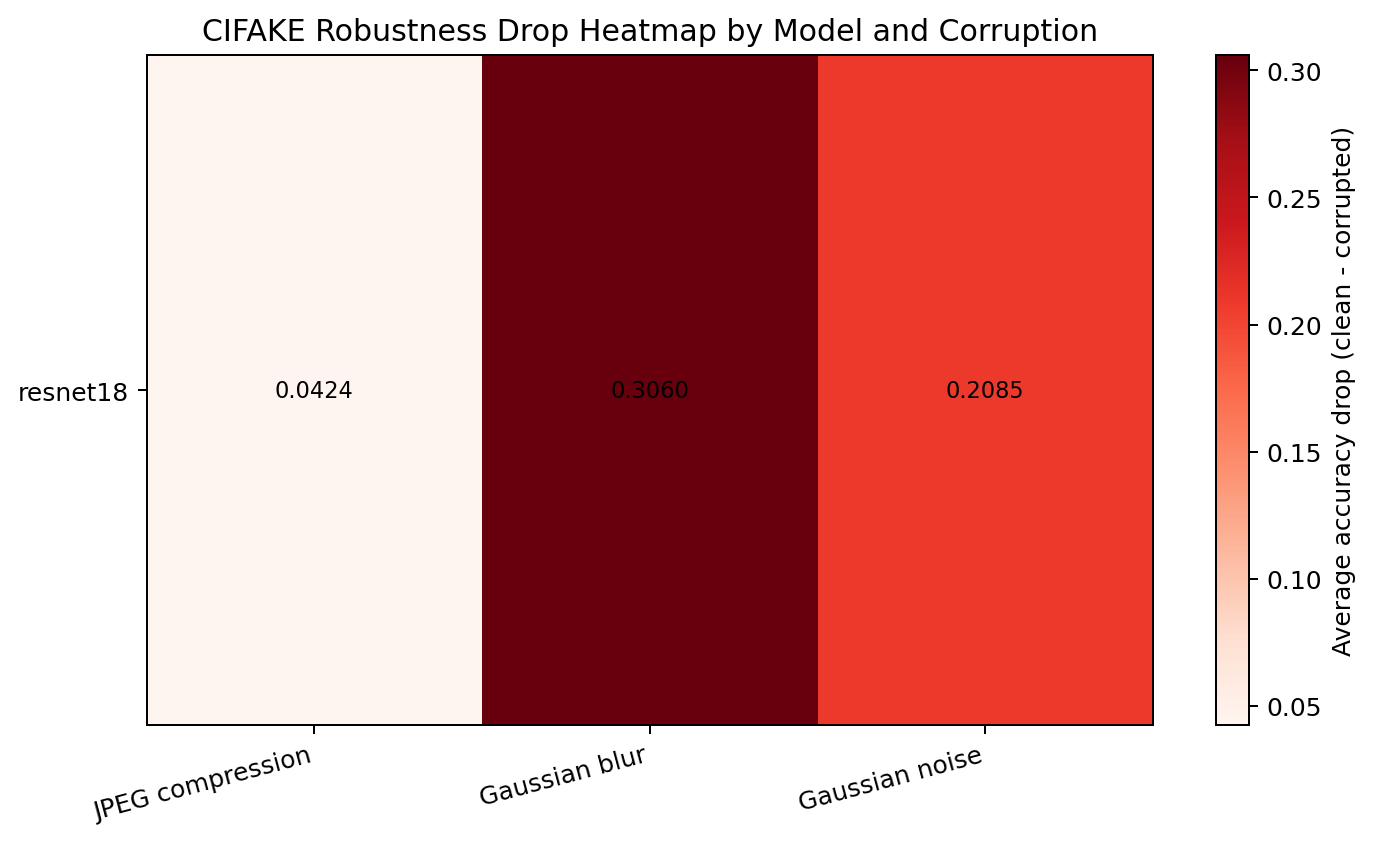

## final_comparison/robustness_curves_all_models.png

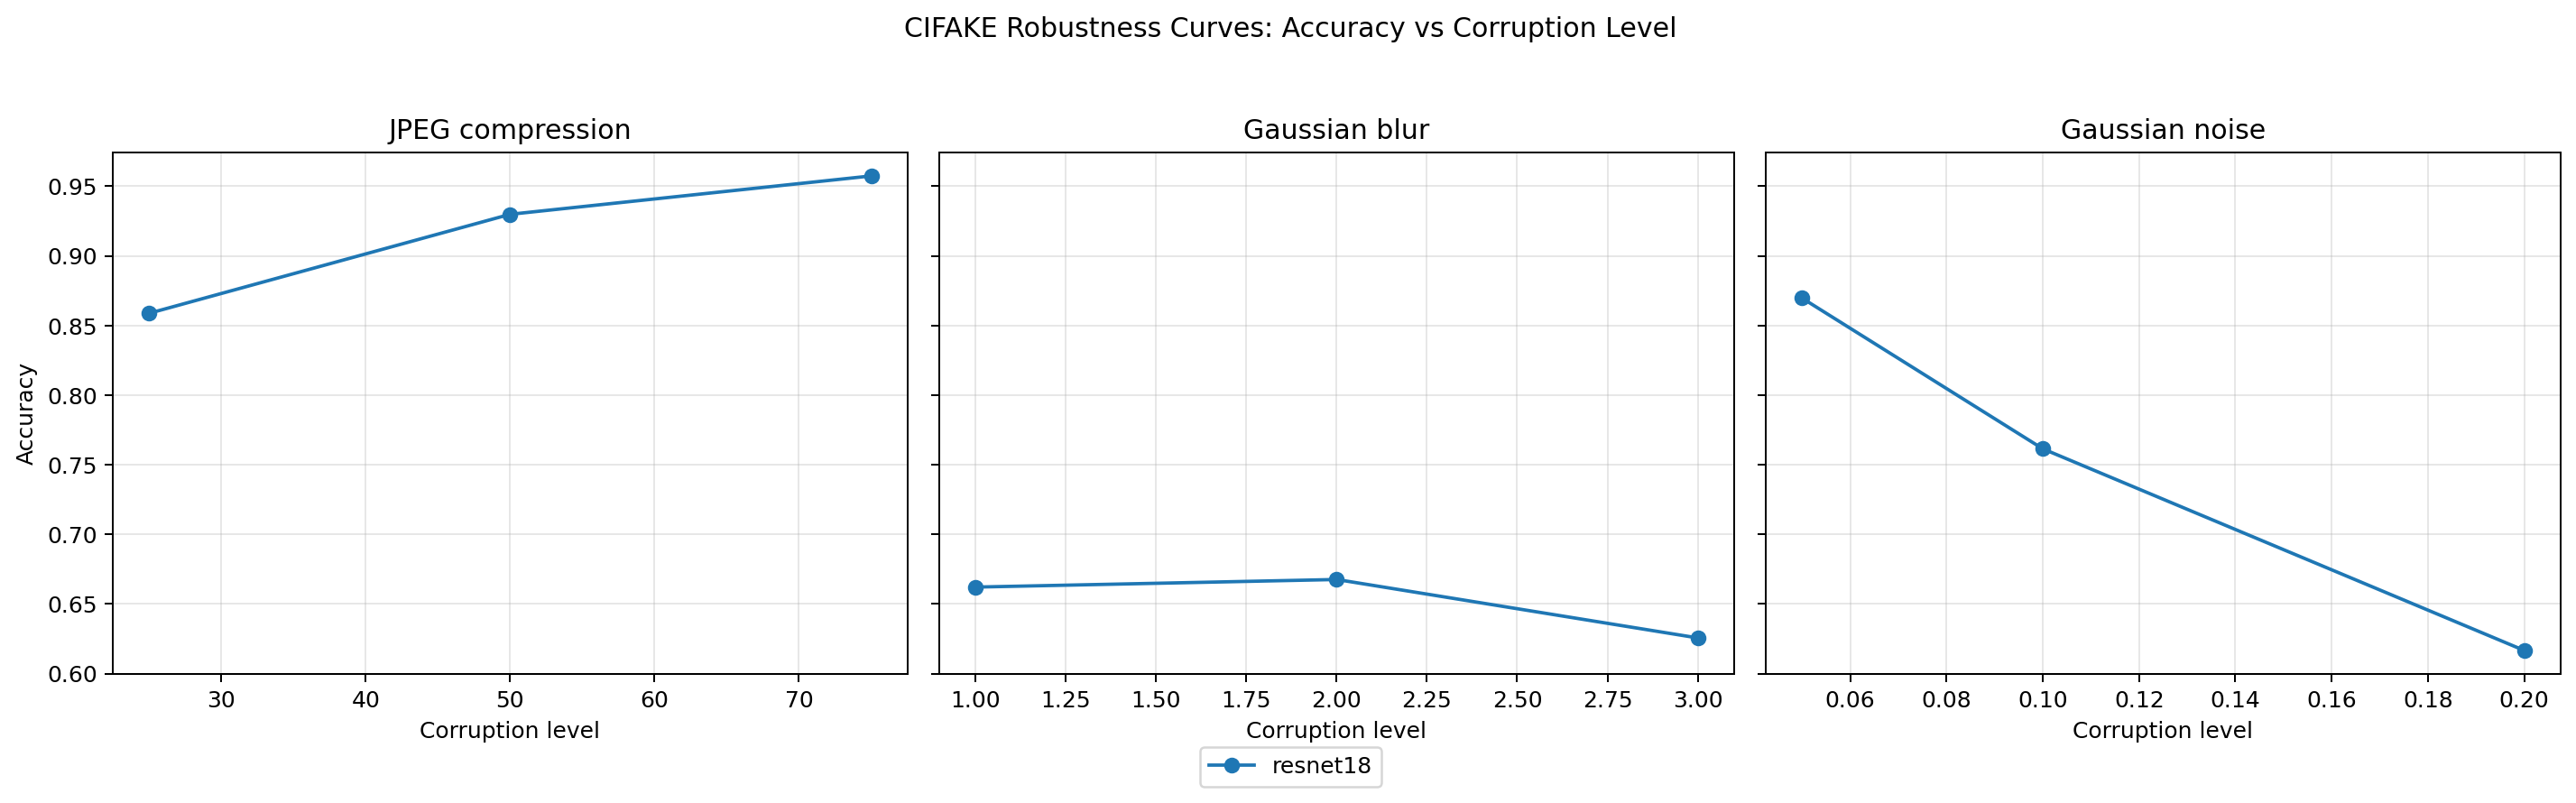

## resnet18/resnet18_confusion_matrix.png

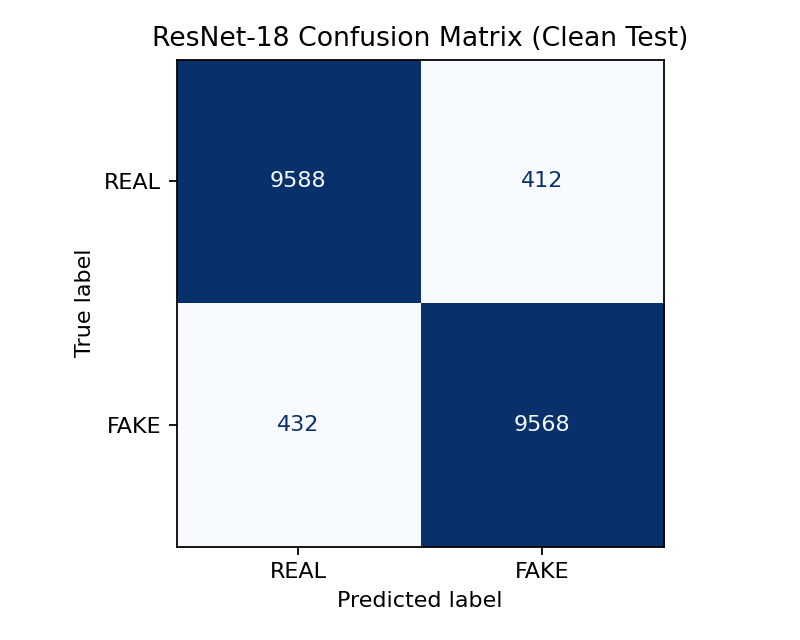

In [17]:
from pathlib import Path
from IPython.display import display, Image, Markdown

base = Path("/kaggle/working/cifake-detection-project/outputs")

png_files = sorted(base.rglob("*.png"))

print(f"Found {len(png_files)} PNG files.\n")

for png in png_files:
    display(Markdown(f"## {png.relative_to(base)}"))
    
    display(Image(filename=str(png)))

## final_comparison/drop_heatmap_all_models.png

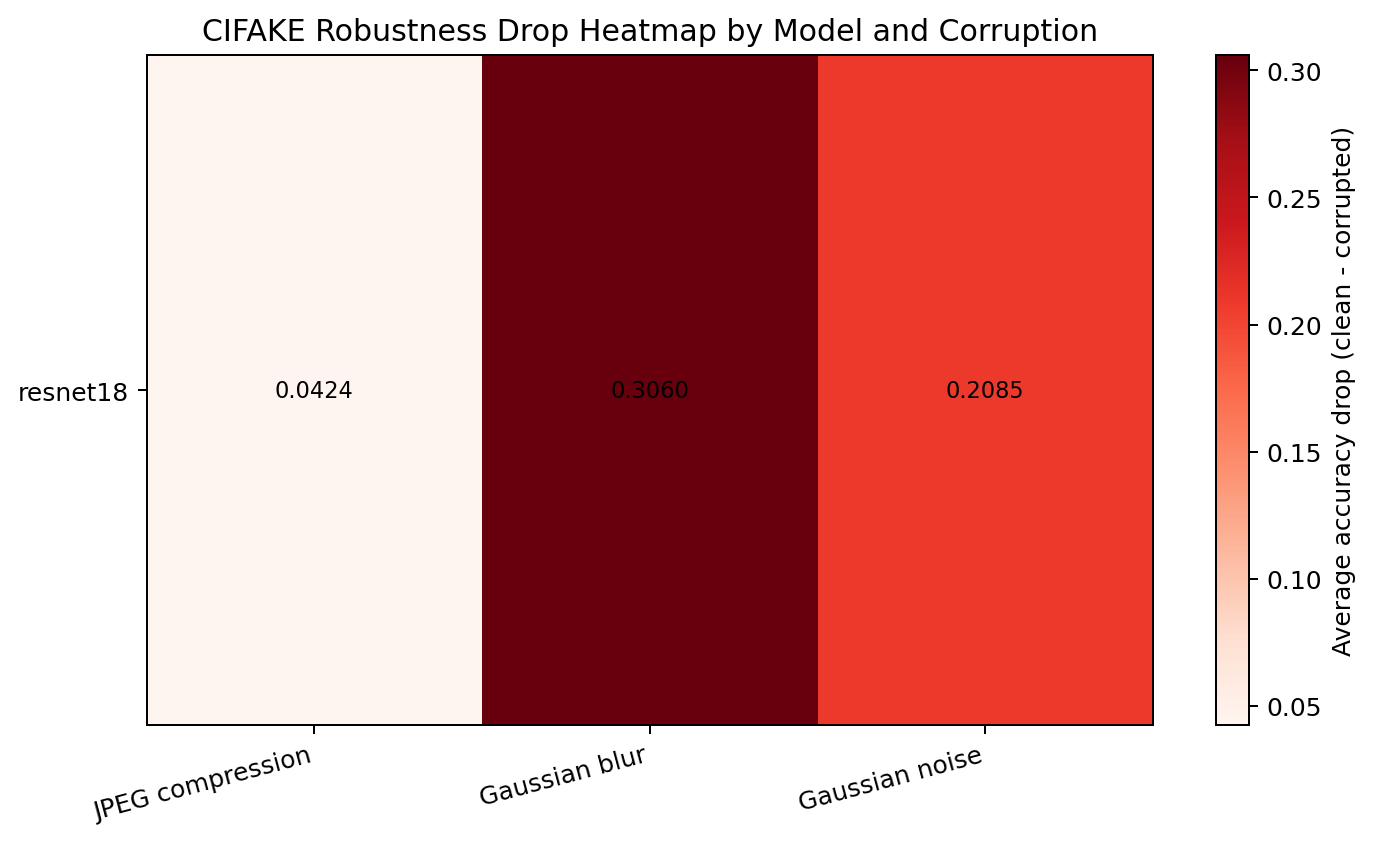

## final_comparison/robustness_curves_all_models.png

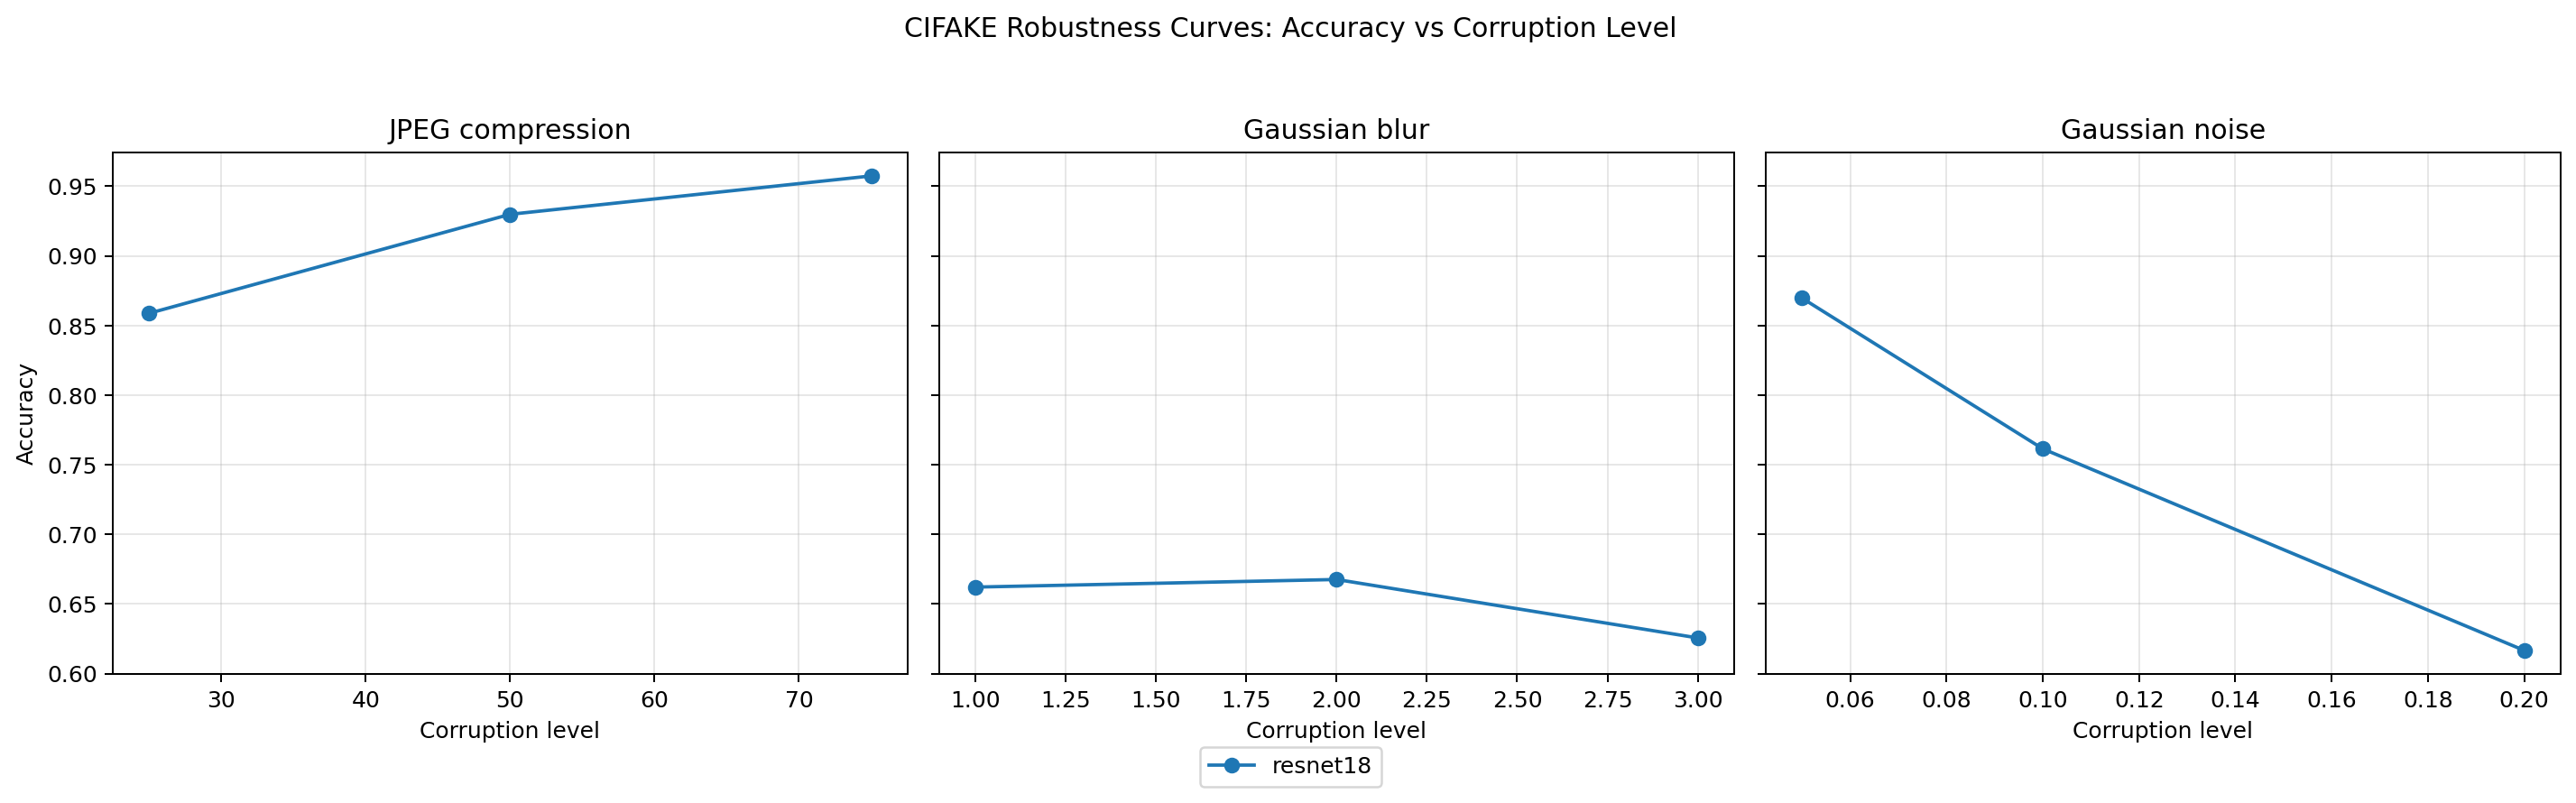

## resnet18/resnet18_confusion_matrix.png

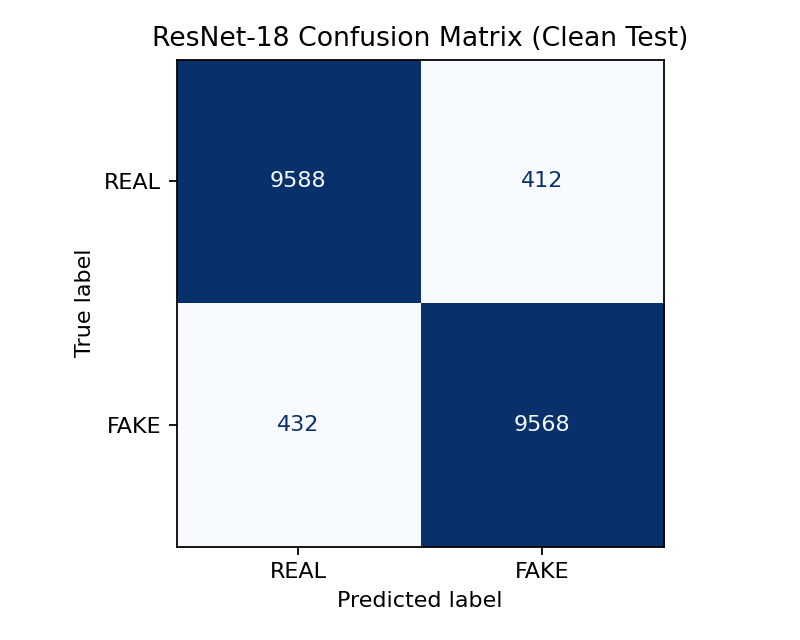

In [18]:
from pathlib import Path
from IPython.display import display, Image, Markdown

base = Path("/kaggle/working/cifake-detection-project/outputs")
for png in sorted(base.rglob("*.png")):
    display(Markdown(f"## {png.relative_to(base)}"))
    display(Image(filename=str(png), width=900))